In [3]:
# 2. Define the path to your compressed file on Drive
file_path = '/content/train.tar'

# 3. Choose the directory to extract to (the fast local Colab drive)
target_dir = '/content/'

# 4. Extract the file (use 'unzip' for .zip, 'tar' for .tar.gz)
!tar -xf {file_path} -C {target_dir}

# Check if files are there
!ls {target_dir}

sample_data  train  train.tar


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import PIL

# from ai_edge_litert.interpreter import Interpreter
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import os

In [ ]:
os.environ["CUDA_VIBLE_DEVICES"] = "-1"
model_mbnv2 = tf.keras.models.load_model("steel_defect_clf_mobile_netv2_fine_tuning_scaling_patch_augmented.keras")

2025-11-09 10:37:11.171302: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
def get_file_size(file_path):
    """Prints the size of a file in MB."""
    size_bytes = os.path.getsize(file_path)
    size_mb = size_bytes / (1024 * 1024)
    return size_mb

In [ ]:
print(f"Size of fine tuned model (MobileNetV2) = {get_file_size('steel_defect_clf_mobile_netv2_fine_tuning.keras')} MB")

Size of fine tuned model (MobileNetV2) = 23.315967559814453 MB


In [2]:
import pathlib

data_dir = pathlib.Path("/content/")
data_dir = data_dir / "train" / "images"
image_count = len(list(data_dir.glob('*/*.jpg')))

batch_size = 32
img_height = 224
img_width = 224

train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  color_mode='grayscale'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=1,
  color_mode='grayscale'
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1799 files belonging to 6 classes.
Using 1440 files for training.
Found 1799 files belonging to 6 classes.
Using 359 files for validation.
Class names: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Number of classes: 6


# 1. Baseline Keras model FP32

In [ ]:
baseline_loss, baseline_acc = model_mbnv2.evaluate(val_ds)

359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9833 - loss: 0.0623


In [ ]:
print(f"Baseline Keras Accuracy: {baseline_acc}")

Baseline Keras Accuracy: 0.9832869172096252


# 2. Post training quantization: weights(FP32 -> INT8)

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_mbnv2)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_dynamic_model = converter.convert()

tflite_dynamic_path = "mobilenetv2_dynamic_ptq.tflite"
with open(tflite_dynamic_path, 'wb') as f:
    f.write(tflite_dynamic_model)

INFO:tensorflow:Assets written to: /tmp/tmpbxasfk8y/assets


INFO:tensorflow:Assets written to: /tmp/tmpbxasfk8y/assets


Saved artifact at '/tmp/tmpbxasfk8y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name='input_layer_16')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  125690999799504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125690999795632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125690999796336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125691000014624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125691000019728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125691000014448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125691000016912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125691000024832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125691000022368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125691000026944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125691000023

W0000 00:00:1762664855.136133   14408 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1762664855.136155   14408 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-11-09 10:37:35.136451: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpbxasfk8y
2025-11-09 10:37:35.146102: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-11-09 10:37:35.146118: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpbxasfk8y
I0000 00:00:1762664855.216142   14408 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2025-11-09 10:37:35.233210: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-11-09 10:37:35.822899: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpbxasfk8y
2025-11-09 10:37:35.949488: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

In [ ]:
TFLITE_DYNAMIC_MODEL_PATH = "mobilenetv2_dynamic_ptq.tflite"
interpreter = Interpreter(model_path=TFLITE_DYNAMIC_MODEL_PATH)
interpreter.allocate_tensors()

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [ ]:
def evaluate_tflite_model(interpreter, val_ds):
    """
    Evaluates the accuracy of a TFLite model on a validation dataset.

    Args:
        interpreter: The loaded and allocated TFLite interpreter.
        val_ds: The tf.data.Dataset to evaluate on.

    Returns:
        The validation accuracy as a float.
    """

    # 1. Get input and output tensor details
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # 2. Initialize lists to store all predictions and labels
    all_predictions = []
    all_labels = []

    print("Running evaluation...")

    # 3. Iterate through the validation dataset
    for images, labels in val_ds:
        # 4. Set the input tensor for each batch
        interpreter.set_tensor(input_details[0]['index'], images)

        # 5. Run inference
        interpreter.invoke()

        # 6. Get the output tensor (the model's predictions)
        output_data = interpreter.get_tensor(output_details[0]['index'])

        # Get the predicted class index by finding the max logit
        predicted_indices = np.argmax(output_data, axis=1)

        # 7. Store predictions and true labels
        all_predictions.extend(predicted_indices)
        all_labels.extend(labels.numpy())

    # 8. Calculate the final accuracy
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)

    accuracy = np.sum(all_predictions == all_labels) / len(all_labels)

    return float(accuracy)

In [ ]:
val_accuracy = evaluate_tflite_model(interpreter, val_ds)

Running evaluation...


2025-11-09 10:37:52.244061: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
val_accuracy

0.9665738161559888

In [ ]:
get_file_size(tflite_dynamic_path)

2.3986282348632812

# 3. PQT FULL INT8

In [ ]:
unbatched_train_ds = train_ds.unbatch()
representative_data = unbatched_train_ds.take(200)

def repr_data_gen():
    for x, _ in train_ds.take(500):
        yield [tf.cast(x, tf.float32)]

def evaluate_full_integer_model(tflite_path, val_ds):
    """
    Evaluates a full-integer TFLite model that requires int8 input.
    """
    interpreter = Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    # Get quantization parameters for input/output
    input_scale, input_zero_point = input_details['quantization']
    output_scale, output_zero_point = output_details['quantization']

    all_predictions = []
    all_labels = []

    print("Running evaluation on full integer model...")

    # Iterate through the validation dataset (which yields float32)
    for images, labels in val_ds:

        images_np = images.numpy()
        labels_np = labels.numpy()

        # Loop through each image in the batch
        # The new model expects batch_size=1 since our generator used it
        for i in range(images_np.shape[0]):
            image = images_np[i:i+1] # Get one image [1, 200, 200, 1]
            label = labels_np[i]

            # --- 1. Quantize the input image ---
            # (float32 / scale) + zero_point = int8
            image_quantized = (image / input_scale) + input_zero_point
            image_quantized = image_quantized.astype(input_details['dtype'])

            # Set the quantized image as input
            interpreter.set_tensor(input_details['index'], image_quantized)
            interpreter.invoke()

            # --- 2. Get the output and de-quantize it ---
            output_quantized = interpreter.get_tensor(output_details['index'])

            # (int8 - zero_point) * scale = float32
            output_float = (output_quantized.astype(np.float32) - output_zero_point) * output_scale

            # Get the final prediction
            predicted_label = np.argmax(output_float[0])

            all_predictions.append(predicted_label)
            all_labels.append(label)

    # Calculate final accuracy
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)

    accuracy = np.sum(all_predictions == all_labels) / len(all_labels)
    return float(accuracy)

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_mbnv2)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = repr_data_gen

# Force full INT8 for MCU compatibility
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8  # For MCUs
converter.inference_output_type = tf.uint8 # For MCUs

tflite_int8_model = converter.convert()

# Save and check
tflite_int8_path = "mobilenetv2_int8_ptq.tflite"
with open(tflite_int8_path, 'wb') as f:
    f.write(tflite_int8_model)
print(f"Saved to {tflite_int8_path}")

INFO:tensorflow:Assets written to: /tmp/tmpn3xymnkh/assets


INFO:tensorflow:Assets written to: /tmp/tmpn3xymnkh/assets


Saved artifact at '/tmp/tmpn3xymnkh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name='input_layer_16')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  125690999799504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125690999795632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125690999796336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125691000014624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125691000019728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125691000014448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125691000016912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125691000024832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125691000022368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125691000026944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125691000023

/home/theorist/Envs/ML-venv/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1762665165.732190   14408 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1762665165.732210   14408 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-11-09 10:42:45.732352: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpn3xymnkh
2025-11-09 10:42:45.741713: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-11-09 10:42:45.741734: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpn3xymnkh
2025-11-09 10:42:45.837612: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-11-09 10:42:46.423545: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp

Saved to mobilenetv2_int8_ptq.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8
2025-11-09 10:44:16.246932: W tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3705] Skipping runtime version metadata in the model. This will be generated by the exporter.


In [ ]:
accuracy = evaluate_full_integer_model(tflite_int8_path, val_ds)
get_file_size(tflite_int8_path)

Running evaluation on full integer model...


2.592681884765625

In [ ]:
accuracy

0.8746518105849582

## we need to patch our fine tuning since image net expects images in [-1, 1] range while ours are in [0, 255]

In [32]:
# Model 3: Fine tuning MobileNetV2

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical", input_shape=(img_height, img_width, 1)),
    layers.RandomRotation(0.10),        # modestly stronger rotation
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.15),
    layers.GaussianNoise(0.01),
], name="data_augmentation")

inputs = layers.Input(shape=(img_height, img_width, 1))

x = data_augmentation(inputs)

# 1. First, convert 1-channel grayscale to 3-channel "pseudo-RGB"
x = layers.Conv2D(3, (1, 1), padding='same')(x)

# 2. THEN, apply the rescaling expected by MobileNetV2
x = layers.Rescaling(1./127.5, offset=-1)(x)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False, # original clf is nto needed
    weights='imagenet'
)

# Freeze the base model
base_model.trainable = False
x = base_model(x, training=False)

# Add our custom clf head for thr 6 defects
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model_3 = tf.keras.Model(inputs, outputs)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_3.compile(optimizer=optimizer,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

model_3.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 3)    │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_9 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,676 (8.64 MB)

 Trainable params: 7,692 (30.05 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [33]:
# PHASE 1
initial_epochs = 10
print("--- Starting Phase 1: Feature Extraction ---")
history_phase1 = model_3.fit(
  train_ds,
  validation_data=val_ds,
  epochs=initial_epochs
)

--- Starting Phase 1: Feature Extraction ---
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 180ms/step - accuracy: 0.4634 - loss: 1.6047 - val_accuracy: 0.9415 - val_loss: 0.3182
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 189ms/step - accuracy: 0.9096 - loss: 0.3062 - val_accuracy: 0.9582 - val_loss: 0.1698
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 166ms/step - accuracy: 0.9516 - loss: 0.1768 - val_accuracy: 0.9805 - val_loss: 0.1273
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 151ms/step - accuracy: 0.9541 - loss: 0.1502 - val_accuracy: 0.9861 - val_loss: 0.0978
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 159ms/step - accuracy: 0.9641 - loss: 0.1154 - val_accuracy: 0.9889 - val_loss: 0.0778
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 151ms/step - accuracy: 0.9721 - loss: 0.0954 - val_accuracy: 0.9889 - val_loss: 0.0711
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step - accuracy: 0.9802 - loss: 0.0755 - val_accuracy: 0.9972 - val_loss: 0.0586
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 151ms/step - accu


--- Starting Phase 2: Fine-Tuning ---
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 193ms/step - accuracy: 0.9813 - loss: 0.0625 - val_accuracy: 0.9944 - val_loss: 0.0148
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - accuracy: 0.9900 - loss: 0.0341 - val_accuracy: 0.9944 - val_loss: 0.0270
Epoch 13/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 158ms/step - accuracy: 0.9884 - loss: 0.0378 - val_accuracy: 0.9944 - val_loss: 0.0224
Epoch 14/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - accuracy: 0.9868 - loss: 0.0433 - val_accuracy: 0.9972 - val_loss: 0.0125
Epoch 15/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 158ms/step - accuracy: 0.9884 - loss: 0.0355 - val_accuracy: 1.0000 - val_loss: 0.0097
Epoch 16/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 162ms/step - accuracy: 0.9965 - loss: 0.0128 - val_accuracy: 0.9972 - val_loss: 0.0125
Epoch 17/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - accuracy: 0.9964 - loss: 0.0154 - val_accuracy: 1.0000 - val_loss: 0.0046
Epoch 18/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 157ms/step - ac

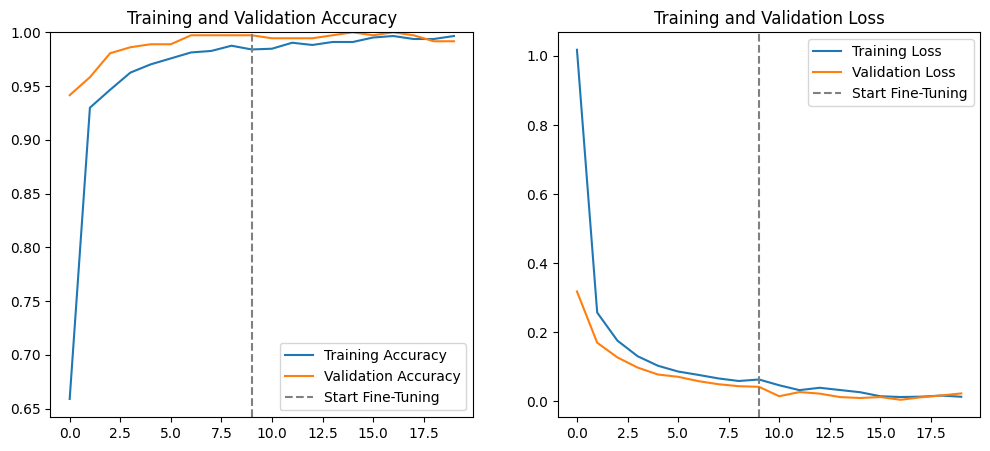

In [34]:
# PHASE 2

base_model.trainable = True
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

# for layer in base_model.layers:
#     if isinstance(layer, tf.keras.layers.BatchNormalization):
#         layer.trainable = False

def freeze_batchnorms(layer):
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    if hasattr(layer, "layers"):
        for sub in layer.layers:
            freeze_batchnorms(sub)

freeze_batchnorms(base_model)

optimizer_fine_tune = tf.keras.optimizers.Adam(learning_rate=1e-5)
model_3.compile(
    optimizer=optimizer_fine_tune,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
print("\n--- Starting Phase 2: Fine-Tuning ---")

fine_tune_epochs = 10
total_epochs = initial_epochs + fine_tune_epochs

history_phase2 = model_3.fit(
    train_ds,
    epochs=total_epochs,
    initial_epoch=initial_epochs,
    validation_data=val_ds,
)

acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']

loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([min(plt.ylim()), 1])
# Add a vertical line to show where fine-tuning started
plt.axvline(initial_epochs - 1, color='gray', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
# Add a vertical line to show where fine-tuning started
plt.axvline(initial_epochs - 1, color='gray', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [35]:
model_3.save('steel_defect_clf_mobile_netv2_fine_tuning_scaling_patch_augmented.keras')

In [ ]:
predictions = model_mbnv2.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)
y_true = np.concatenate([y for x, y in val_ds], axis=0)

359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step


2025-11-09 09:14:19.016351: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        52
      inclusion       1.00      0.97      0.99        75
        patches       1.00      1.00      1.00        56
 pitted_surface       1.00      1.00      1.00        59
rolled-in_scale       1.00      1.00      1.00        61
      scratches       0.97      1.00      0.98        56

       accuracy                           0.99       359
      macro avg       0.99      1.00      0.99       359
   weighted avg       0.99      0.99      0.99       359



In [ ]:
confidences = np.max(predictions, axis=1)
for i in range(100):
    print(f"Sample {i}:")
    print(f"  Predicted class: {y_pred[i]}")
    print(f"  Confidence: {confidences[i]:.2%}")

Sample 0:
  Predicted class: 4
  Confidence: 100.00%
Sample 1:
  Predicted class: 1
  Confidence: 99.98%
Sample 2:
  Predicted class: 5
  Confidence: 100.00%
Sample 3:
  Predicted class: 0
  Confidence: 100.00%
Sample 4:
  Predicted class: 3
  Confidence: 100.00%
Sample 5:
  Predicted class: 1
  Confidence: 99.99%
Sample 6:
  Predicted class: 4
  Confidence: 100.00%
Sample 7:
  Predicted class: 1
  Confidence: 99.50%
Sample 8:
  Predicted class: 5
  Confidence: 100.00%
Sample 9:
  Predicted class: 4
  Confidence: 100.00%
Sample 10:
  Predicted class: 5
  Confidence: 99.97%
Sample 11:
  Predicted class: 5
  Confidence: 100.00%
Sample 12:
  Predicted class: 5
  Confidence: 100.00%
Sample 13:
  Predicted class: 1
  Confidence: 99.99%
Sample 14:
  Predicted class: 2
  Confidence: 100.00%
Sample 15:
  Predicted class: 3
  Confidence: 99.99%
Sample 16:
  Predicted class: 3
  Confidence: 99.98%
Sample 17:
  Predicted class: 0
  Confidence: 99.99%
Sample 18:
  Predicted class: 0
  Confidence: 

# 3. quantization aware training

In [ ]:
import tensorflow_model_optimization as tfmot

In [ ]:
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

num_images = len(train_ds)
end_step = np.ceil(num_images / batch_size).astype(np.int32) * 2

# 50% pruning
pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(initial_sparsity=0.50, final_sparsity=0.80, begin_step=0, end_step=end_step)
}